<a href="https://colab.research.google.com/github/ruhmmachaudhary-rgb/AI-ML-Fellowship-GDGOC-Atk/blob/main/week5/model-evalution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression Metrics:
MAE: 0.591, MSE: 0.654, RMSE: 0.809, R²: 0.807


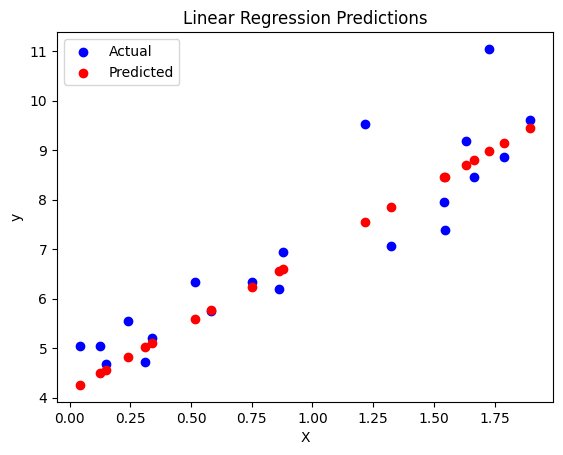

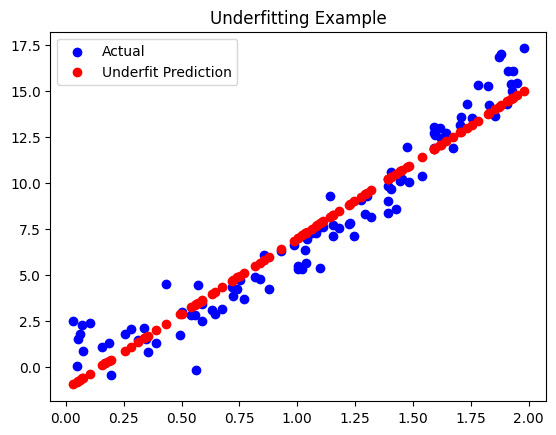

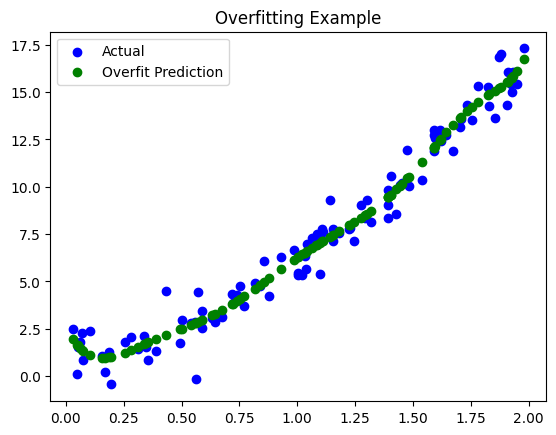

Logistic Regression Metrics:
Accuracy: 1.000, Precision: 1.000, Recall: 1.000, F1: 1.000
Confusion Matrix:
 [[25  0]
 [ 0 15]]


In [1]:
"""
Week 5: Model Evaluation, Overfitting & Underfitting Demo
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

"""
1️ Regression Metrics Demo
"""
np.random.seed(42)
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Metrics:")
print(f"MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.title("Linear Regression Predictions")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

"""
2️ Demonstrating Underfitting & Overfitting (Regression)
"""
X_quad = 2 * np.random.rand(100,1)
y_quad = 1 + 2*X_quad + 3*X_quad**2 + np.random.randn(100,1)

lin_underfit = LinearRegression()
lin_underfit.fit(X_quad, y_quad)
y_pred_underfit = lin_underfit.predict(X_quad)

plt.scatter(X_quad, y_quad, color='blue', label='Actual')
plt.scatter(X_quad, y_pred_underfit, color='red', label='Underfit Prediction')
plt.title("Underfitting Example")
plt.legend()
plt.show()

poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X_quad)
lin_overfit = LinearRegression()
lin_overfit.fit(X_poly, y_quad)
y_pred_overfit = lin_overfit.predict(X_poly)

plt.scatter(X_quad, y_quad, color='blue', label='Actual')
plt.scatter(X_quad, y_pred_overfit, color='green', label='Overfit Prediction')
plt.title("Overfitting Example")
plt.legend()
plt.show()

"""
3️ Classification Metrics Demo
"""
X_clf = np.random.randn(200, 2)
y_clf = (X_clf[:,0] + X_clf[:,1] > 0).astype(int)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

clf_model = LogisticRegression()
clf_model.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf)

accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)
cm = confusion_matrix(y_test_clf, y_pred_clf)

print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
print("Confusion Matrix:\n", cm)